# Thesis Figures
Single notebook that reproduces every figure in the thesis from pre-computed result files.
Run `evaluation.py` (regression) and the classification evaluation script on Alvis first
to generate the `.pkl` and `.csv` result files, then run this notebook locally.

---
### Sections
1. Setup & style
2. PROTAC synthesizability figures
3. Regression model figures
4. Classification model figures *(placeholder — add script outputs when ready)*


## 1. Setup & style

In [1]:
# Change these to switch between experiments/runs
EXPERIMENT = "full"     # surrogate model experiment prefix
RUN_NAME   = "full_dataset"  # scoring run name


In [2]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
REPO_ROOT   = Path("../").resolve()
SURROGATE   = REPO_ROOT / "data" / "processed" / "surrogate_model"
SCORES  = REPO_ROOT / "data" / "processed" / "scores" / RUN_NAME
REG_RESULTS = SURROGATE / "results" / "regression" / EXPERIMENT
CL_RESULTS  = SURROGATE / "results" / "classification" / EXPERIMENT
FIGURES     = REPO_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

print(f"Experiment  : '{EXPERIMENT}'")
print(f"Run name    : '{RUN_NAME}'")
print(f"Figures dir : {FIGURES}")
print(f"Scores dir  : {SCORES}")


Experiment  : 'full'
Run name    : 'full_dataset'
Figures dir : /mimer/NOBACKUP/groups/naiss2023-6-290/tingtingmo/matser_thesis_2026_PROTAC_Synthesizability/figures
Scores dir  : /mimer/NOBACKUP/groups/naiss2023-6-290/tingtingmo/matser_thesis_2026_PROTAC_Synthesizability/data/processed/scores/full_dataset


In [3]:
# ---------------------------------------------------------------------------
# AIME colour palette
# ---------------------------------------------------------------------------
DEEP_TEAL     = "#2D4F54"
ROYAL_PURPLE  = "#7B539E"
SOFT_LAVENDER = "#B8A0D2"
FOREST_GREEN  = "#5A9448"
MUTED_PLUM    = "#9E4A78"
DARK_SLATE    = "#3A3D4A"

AIME_PALETTE = [
    DEEP_TEAL, ROYAL_PURPLE, SOFT_LAVENDER,
    FOREST_GREEN, MUTED_PLUM, DARK_SLATE,
]

# ---------------------------------------------------------------------------
# Matplotlib rcParams (AIME style guide)
# ---------------------------------------------------------------------------
AIME_RCPARAMS = {
    "font.family":         "sans-serif",
    "font.sans-serif":     ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":           11,
    "axes.facecolor":      "white",
    "axes.edgecolor":      DARK_SLATE,
    "axes.linewidth":      1.2,
    "axes.labelcolor":     DARK_SLATE,
    "axes.labelsize":      11,
    "axes.spines.top":     True,
    "axes.spines.right":   True,
    "axes.prop_cycle":     plt.cycler("color", AIME_PALETTE),
    "axes.grid":           False,
    "xtick.color":         DARK_SLATE,
    "ytick.color":         DARK_SLATE,
    "xtick.labelsize":     9.5,
    "ytick.labelsize":     9.5,
    "xtick.major.width":   1.0,
    "ytick.major.width":   1.0,
    "xtick.major.size":    4.5,
    "ytick.major.size":    4.5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.direction":     "out",
    "ytick.direction":     "out",
    "legend.frameon":      False,
    "legend.fontsize":     9.5,
    "legend.labelcolor":   DARK_SLATE,
    "figure.facecolor":    "white",
    "figure.dpi":          150,
    "savefig.dpi":         300,
    "savefig.bbox":        "tight",
    "savefig.facecolor":   "white",
    "lines.linewidth":     1.8,
    "lines.markersize":    5.5,
}

plt.rcParams.update(AIME_RCPARAMS)
print("AIME style applied.")

AIME style applied.


In [4]:
# ---------------------------------------------------------------------------
# Helper: panel label (AIME style guide)
# ---------------------------------------------------------------------------
def add_panel_label(ax, label):
    """Place a bold panel label outside the axes, left of the y-tick labels."""
    ax.text(
        -0.18, 0.97, label,
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left", color=DARK_SLATE,
    )


# ---------------------------------------------------------------------------
# Helper: save figure as PNG + PDF
# ---------------------------------------------------------------------------
def save_fig(fig, name: str):
    """Save to figures/ as both PNG (300 dpi) and PDF."""
    fig.savefig(FIGURES / f"{name}.png", dpi=300)
    fig.savefig(FIGURES / f"{name}.pdf")
    print(f"Saved: figures/{name}.png  +  figures/{name}.pdf")

---
## 2. Synthesizability score figures

**Prerequisites:** run on Alvis:
```bash
python src/protac_synthesizability/get_scores.py --input_csv ... --output_prefix data/processed/scores/{RUN_NAME}/{RUN_NAME}
python src/protac_synthesizability/merge_results.py data/processed/scores/{RUN_NAME}/
```
Then download `data/processed/scores/{RUN_NAME}/{RUN_NAME}_merged_summary.csv` locally.

In [19]:
# ---------------------------------------------------------------------------
# Load scoring results
# ---------------------------------------------------------------------------
summary_df = pd.read_csv(SCORES / f"{RUN_NAME}_summary.csv")

# Solved: all precursors in stock
if "solved" not in summary_df.columns:
    summary_df["solved"] = (summary_df["in_stock"] == summary_df["precursors"]).astype(int)

solved_df   = summary_df[summary_df["solved"] == 1]
unsolved_df = summary_df[summary_df["solved"] == 0]

print(f"Total molecules : {len(summary_df)}")
print(f"Solved          : {len(solved_df)} ({len(solved_df)/len(summary_df)*100:.1f}%)")
print(f"Unsolved        : {len(unsolved_df)} ({len(unsolved_df)/len(summary_df)*100:.1f}%)")


Total molecules : 27099
Solved          : 20011 (73.8%)
Unsolved        : 7088 (26.2%)


In [20]:
# ---------------------------------------------------------------------------
# Table S-1: Descriptive statistics — export to LaTeX
# ---------------------------------------------------------------------------
def compute_stats(series):
    return {
        "Mean":   series.mean(),
        "Median": series.median(),
        "Std":    series.std(),
        "Min":    series.min(),
        "Max":    series.max(),
        "p90":    series.quantile(0.90),
        "p95":    series.quantile(0.95),
    }

metrics = {
    ("Solved",   "AiZynthFinder score"): compute_stats(solved_df["aizynthfinder_score"]),
    ("Solved",   "HAC-weighted score"):  compute_stats(solved_df["hac_weighted_score"]),
    ("Solved",   "Search time (s)"):     compute_stats(solved_df["search_time_seconds"]),
    ("Unsolved", "AiZynthFinder score"): compute_stats(unsolved_df["aizynthfinder_score"]),
    ("Unsolved", "HAC-weighted score"):  compute_stats(unsolved_df["hac_weighted_score"]),
    ("Unsolved", "Search time (s)"):     compute_stats(unsolved_df["search_time_seconds"]),
}

stats_df = pd.DataFrame(metrics).T
stats_df.index = pd.MultiIndex.from_tuples(stats_df.index, names=["Group", "Metric"])

print(stats_df.round(3).to_string())
print("\nLaTeX:")
print(
    stats_df.round(3).to_latex(
        caption="Descriptive statistics for AiZynthFinder scoring results.",
        label="tab:score_stats",
        column_format="llrrrrrrr",
        multirow=True,
    )
)


                                 Mean   Median     Std    Min      Max      p90      p95
Group    Metric                                                                         
Solved   AiZynthFinder score    0.960    0.951   0.016  0.950    0.998    0.987    0.998
         HAC-weighted score     0.973    0.975   0.017  0.867    0.998    0.992    0.998
         Search time (s)       35.359    4.434  88.200  0.032  712.162   91.490  213.494
Unsolved AiZynthFinder score    0.867    0.891   0.129  0.049    0.922    0.907    0.910
         HAC-weighted score     0.740    0.773   0.139  0.050    0.940    0.848    0.862
         Search time (s)      596.673  605.852  94.567  0.085  828.895  627.285  637.352

LaTeX:
\begin{table}
\caption{Descriptive statistics for AiZynthFinder scoring results.}
\label{tab:score_stats}
\begin{tabular}{llrrrrrrr}
\toprule
 &  & Mean & Median & Std & Min & Max & p90 & p95 \\
Group & Metric &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{Solved} & AiZynthF

Saved: figures/full_dataset_score_distributions.png  +  figures/full_dataset_score_distributions.pdf


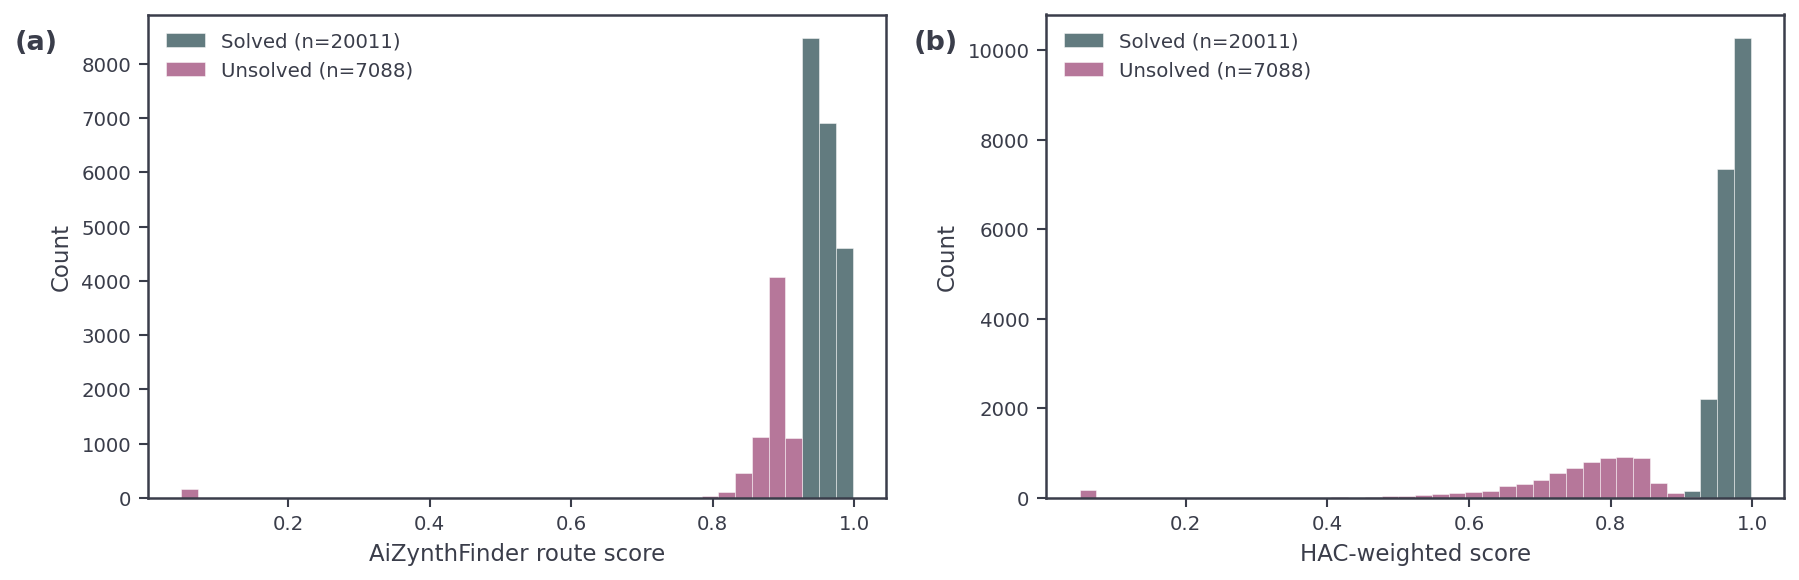

In [21]:
# ---------------------------------------------------------------------------
# Fig S-1: Score distributions
# ---------------------------------------------------------------------------
def plot_score_distributions(solved_df, unsolved_df, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, col, xlabel in zip(
        axes,
        ["aizynthfinder_score", "hac_weighted_score"],
        ["AiZynthFinder route score", "HAC-weighted score"],
    ):
        all_vals = pd.concat([solved_df[col], unsolved_df[col]])
        bins = np.linspace(all_vals.min(), all_vals.max(), 41)
        ax.hist(solved_df[col],   bins=bins, color=DEEP_TEAL,  alpha=0.75,
                edgecolor="white", linewidth=0.3, label=f"Solved (n={len(solved_df)})")
        ax.hist(unsolved_df[col], bins=bins, color=MUTED_PLUM, alpha=0.75,
                edgecolor="white", linewidth=0.3, label=f"Unsolved (n={len(unsolved_df)})")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.legend()

    add_panel_label(axes[0], "(a)")
    add_panel_label(axes[1], "(b)")
    plt.tight_layout(w_pad=2.0)
    save_fig(fig, name)
    plt.show()


plot_score_distributions(solved_df, unsolved_df, name=f"{RUN_NAME}_score_distributions")


Saved: figures/full_dataset_score_scatter.png  +  figures/full_dataset_score_scatter.pdf


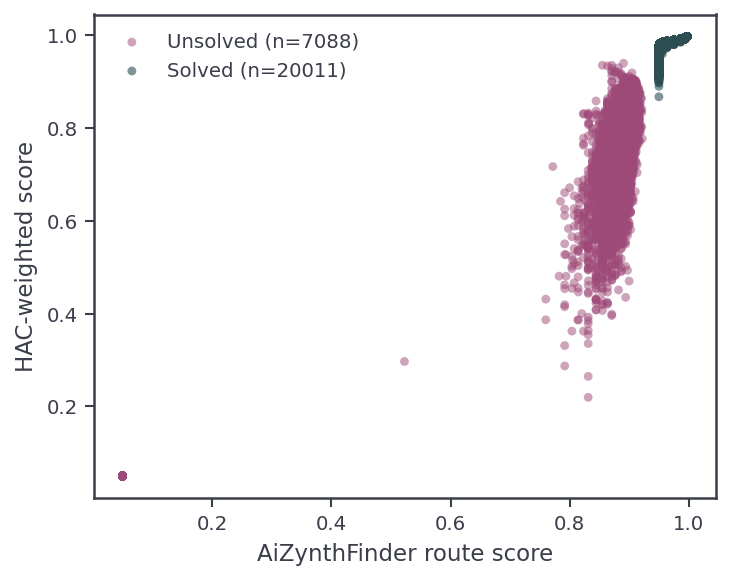

In [22]:
# ---------------------------------------------------------------------------
# Fig S-2: Scatter — AiZynthFinder score vs HAC-weighted score
# ---------------------------------------------------------------------------
def plot_score_scatter(solved_df, unsolved_df, name):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(
        unsolved_df["aizynthfinder_score"], unsolved_df["hac_weighted_score"],
        color=MUTED_PLUM, alpha=0.5, s=18, edgecolors="none",
        label=f"Unsolved (n={len(unsolved_df)})",
    )
    ax.scatter(
        solved_df["aizynthfinder_score"], solved_df["hac_weighted_score"],
        color=DEEP_TEAL, alpha=0.6, s=18, edgecolors="none",
        label=f"Solved (n={len(solved_df)})",
    )
    ax.set_xlabel("AiZynthFinder route score")
    ax.set_ylabel("HAC-weighted score")
    ax.legend()
    plt.tight_layout()
    save_fig(fig, name)
    plt.show()


plot_score_scatter(solved_df, unsolved_df, name=f"{RUN_NAME}_score_scatter")


### HAC score and AiZynthFinder score — filtered vs unfiltered

Filtered dataset: 22862 molecules
Saved: figures/full_dataset_score_kde_filtered_vs_full.png  +  figures/full_dataset_score_kde_filtered_vs_full.pdf


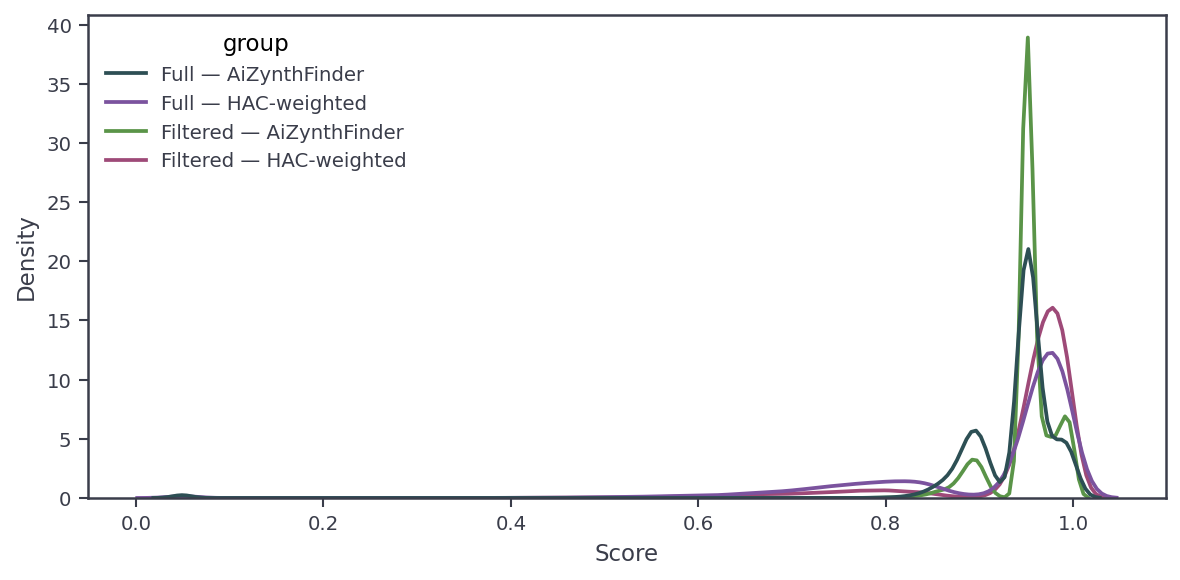

In [26]:
# ---------------------------------------------------------------------------
# Fig S-4: KDE — score distributions filtered vs unfiltered
# ---------------------------------------------------------------------------
# Set this to your filtered scoring run name once available
FILTERED_RUN_NAME = "exp2_protacs_filtered.csv"  # <-- update this

FILTERED_SCORES_DIR = REPO_ROOT / "data" / "processed" 
filtered_summary_df = pd.read_csv(
    FILTERED_SCORES_DIR / f"{FILTERED_RUN_NAME}"
)
if "solve_tag" not in filtered_summary_df.columns:
    filtered_summary_df["solve_tag"] = (
        filtered_summary_df["in_stock"] == filtered_summary_df["precursors"]
    ).astype(int)

print(f"Filtered dataset: {len(filtered_summary_df)} molecules")


def plot_score_kde_filtered_vs_full(full_df, filtered_df, name):
    palette = {
        "Full — AiZynthFinder":  DEEP_TEAL,
        "Full — HAC-weighted":   ROYAL_PURPLE,
        "Filtered — AiZynthFinder": FOREST_GREEN,
        "Filtered — HAC-weighted":  MUTED_PLUM,
    }

    plot_df = pd.concat([
        pd.DataFrame({
            "score": full_df["aizynthfinder_score"],
            "group": "Full — AiZynthFinder",
        }),
        pd.DataFrame({
            "score": full_df["hac_weighted_score"],
            "group": "Full — HAC-weighted",
        }),
        pd.DataFrame({
            "score": filtered_df["aizynthfinder_score"],
            "group": "Filtered — AiZynthFinder",
        }),
        pd.DataFrame({
            "score": filtered_df["hac_weighted_score"],
            "group": "Filtered — HAC-weighted",
        }),
    ], ignore_index=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.kdeplot(
        data=plot_df, x="score", hue="group",
        palette=palette, ax=ax,
        fill=False, linewidth=1.8, common_norm=False,
    )
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    plt.tight_layout()
    save_fig(fig, name)
    plt.show()


plot_score_kde_filtered_vs_full(
    summary_df, filtered_summary_df,
    name=f"{RUN_NAME}_score_kde_filtered_vs_full"
)


### Molecular property comparison — full dataset vs 1000 diverse subset

In [23]:
# ---------------------------------------------------------------------------
# Load diverse subset and compute properties
# ---------------------------------------------------------------------------
DIVERSE_CSV   = REPO_ROOT / "data" / "processed" / "1000_protacs.csv"
diverse_df    = pd.read_csv(DIVERSE_CSV)

def compute_properties(smiles_list):
    records = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        records.append({
            "MW":       Descriptors.MolWt(mol),
            "HAC":      mol.GetNumHeavyAtoms(),
            "LogP":     Descriptors.MolLogP(mol),
            "TPSA":     Descriptors.TPSA(mol),
            "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
            "Rings":    rdMolDescriptors.CalcNumRings(mol),
        })
    return pd.DataFrame(records)

print("Computing properties for full dataset...")
full_props    = compute_properties(summary_df["molecule"].dropna().tolist())
print("Computing properties for diverse subset...")
diverse_props = compute_properties(diverse_df["protac_smiles_std"].dropna().tolist())

full_props["subset"]    = "Full dataset"
diverse_props["subset"] = "1000 diverse subset"
combined = pd.concat([full_props, diverse_props], ignore_index=True)

PROPS = ["MW", "HAC", "LogP", "TPSA", "RotBonds", "Rings"]
print(f"Full dataset: {len(full_props)} molecules")
print(f"Diverse subset: {len(diverse_props)} molecules")


Computing properties for full dataset...
Computing properties for diverse subset...
Full dataset: 27099 molecules
Diverse subset: 1000 molecules


Saved: figures/full_dataset_property_kde.png  +  figures/full_dataset_property_kde.pdf


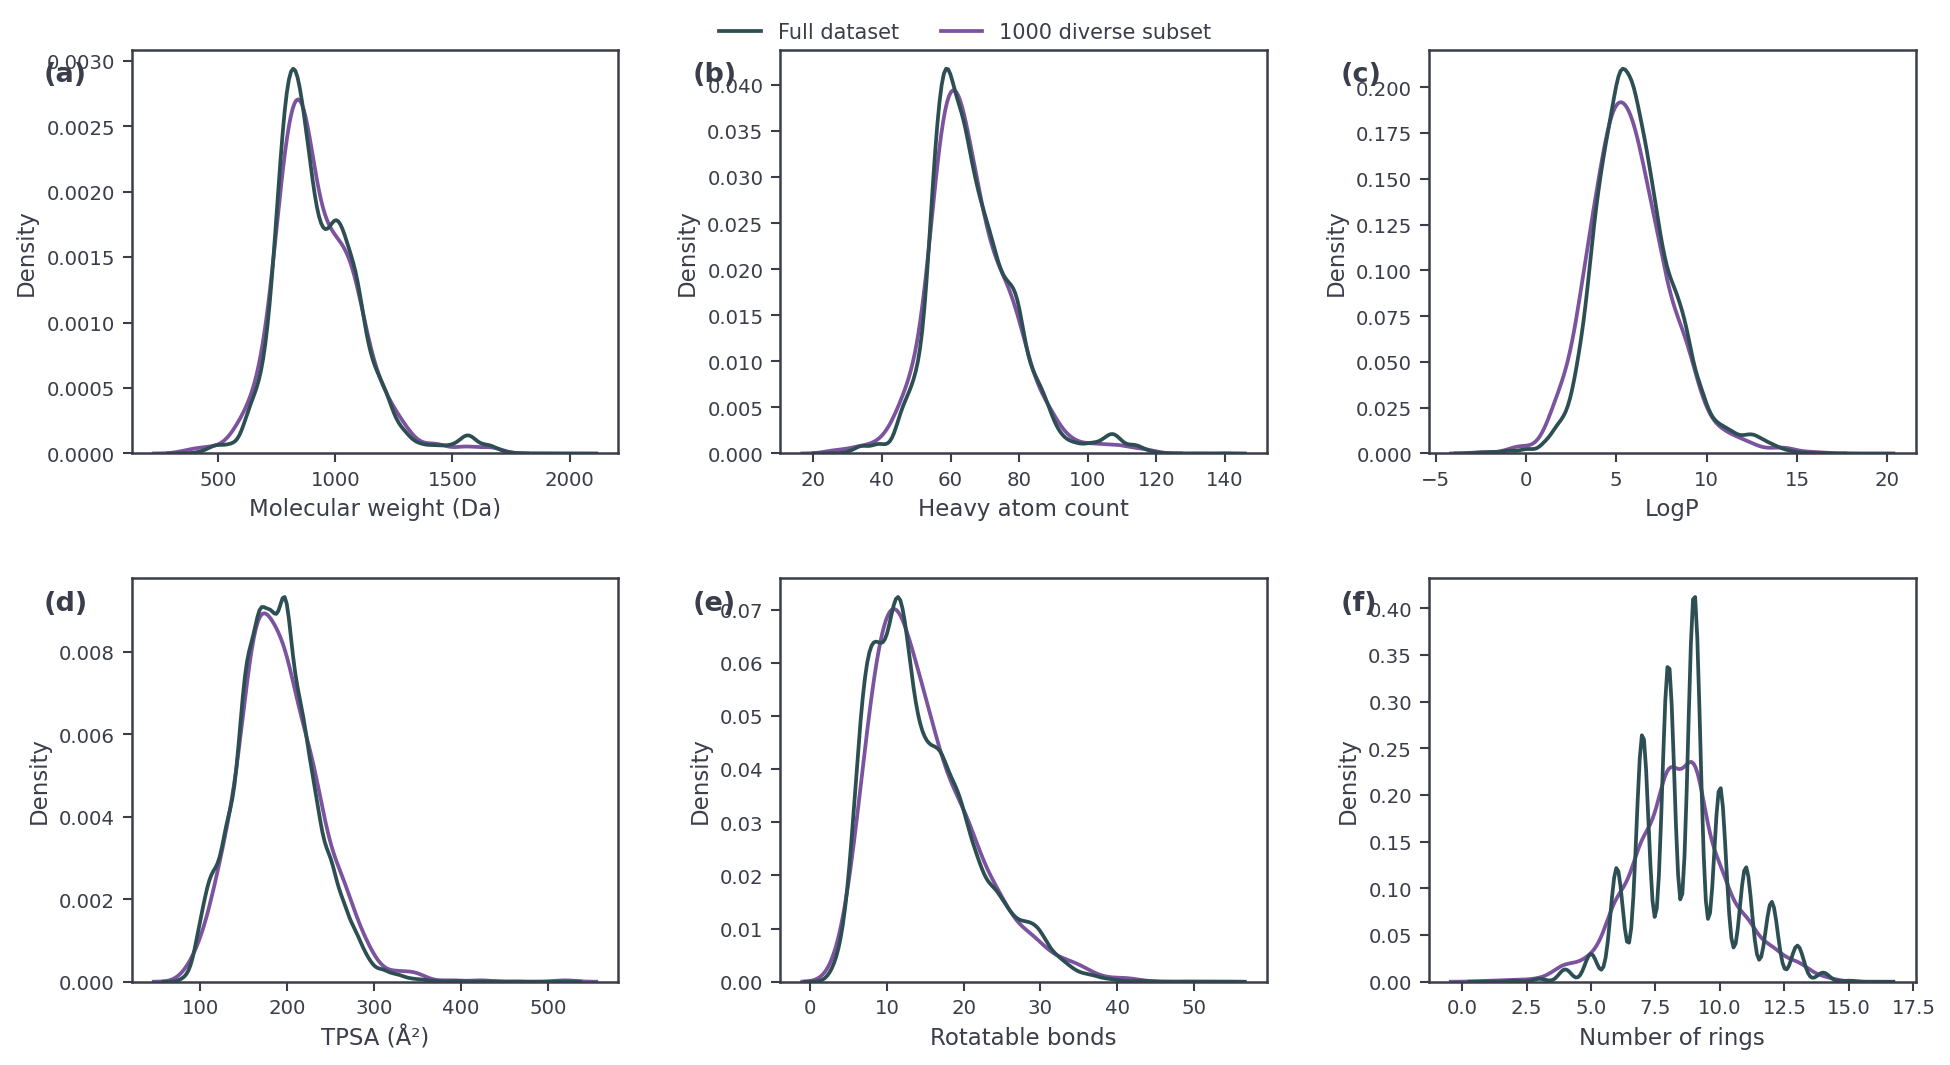

In [24]:
# ---------------------------------------------------------------------------
# Fig S-3: KDE — molecular property distributions
# ---------------------------------------------------------------------------
def plot_property_kde(combined, props, name):
    palette = {
        "Full dataset":        DEEP_TEAL,
        "1000 diverse subset": ROYAL_PURPLE,
    }
    prop_labels = {
        "MW":       "Molecular weight (Da)",
        "HAC":      "Heavy atom count",
        "LogP":     "LogP",
        "TPSA":     "TPSA (\u00c5\u00b2)",
        "RotBonds": "Rotatable bonds",
        "Rings":    "Number of rings",
    }
    panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    for ax, prop, panel in zip(axes.flat, props, panel_labels):
        sns.kdeplot(
            data=combined, x=prop, hue="subset",
            palette=palette, ax=ax,
            fill=False, linewidth=1.8, common_norm=False,
            legend=False,
        )
        ax.set_xlabel(prop_labels.get(prop, prop))
        ax.set_ylabel("Density")
        add_panel_label(ax, panel)

    handles = [
        plt.Line2D([0], [0], color=DEEP_TEAL,    linewidth=1.8, label="Full dataset"),
        plt.Line2D([0], [0], color=ROYAL_PURPLE, linewidth=1.8, label="1000 diverse subset"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2,
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout(h_pad=2.5, w_pad=2.0)
    save_fig(fig, name)
    plt.show()


plot_property_kde(combined, PROPS, name=f"{RUN_NAME}_property_kde")


In [25]:
# ---------------------------------------------------------------------------
# Table S-2: Property statistics — export to LaTeX
# ---------------------------------------------------------------------------
stats_df = (
    combined
    .groupby("subset")[PROPS]
    .agg(["median", "mean", "std"])
    .round(2)
)
print(stats_df.to_string())
print("\nLaTeX:")
print(
    stats_df.to_latex(
        caption="Molecular property statistics for the full dataset and the 1000 diverse subset.",
        label="tab:property_stats",
        multirow=True,
        multicolumn=True,
    )
)


                         MW                    HAC                 LogP                TPSA                RotBonds               Rings            
                     median    mean     std median   mean    std median  mean   std  median    mean    std   median   mean   std median  mean   std
subset                                                                                                                                             
1000 diverse subset  889.88  921.50  178.75   64.0  65.83  12.27   5.57  5.75  2.27  187.23  192.47  47.73     13.0  14.89  6.67    8.0  8.44  1.90
Full dataset         893.95  929.79  183.84   64.0  66.56  12.45   5.83  6.07  2.21  185.53  187.71  44.04     13.0  14.61  6.76    9.0  8.68  1.85

LaTeX:
\begin{table}
\caption{Molecular property statistics for the full dataset and the 1000 diverse subset.}
\label{tab:property_stats}
\begin{tabular}{lrrrrrrrrrrrrrrrrrr}
\toprule
 & \multicolumn{3}{r}{MW} & \multicolumn{3}{r}{HAC} & \multicolumn{3}{r}{Lo

---
## 3. Regression model figures

**Prerequisites:** run `evaluation.py` on Alvis first. It should save:
- `{PREFIX}cv_fold_scores.pkl`
- `{PREFIX}test_predictions.pkl`
- `{PREFIX}test_metrics.csv`

into `data/processed/surrogate_model/`.

In [25]:
# ---------------------------------------------------------------------------
# Load regression results
# ---------------------------------------------------------------------------
with open(REG_RESULTS / "cv_fold_scores.pkl", "rb") as f:
    fold_scores = pickle.load(f)   # {label: [fold_r2, ...]}

with open(REG_RESULTS / "test_predictions.pkl", "rb") as f:
    pred_data = pickle.load(f)     # {label: {"y_pred": ..., "y_true": ...}}

metrics_df = pd.read_csv(REG_RESULTS / "test_metrics.csv", index_col=0)

print(f"Loaded {len(fold_scores)} configurations.")
print(metrics_df)

# ---------------------------------------------------------------------------
# Build long-format CV DataFrame for statistical tests (Ash et al. format)
# ---------------------------------------------------------------------------
rows = []
for label, scores in fold_scores.items():
    for i, score in enumerate(scores):
        rows.append({"cv_cycle": i, "method": label, "r2": score})

df_cv = pd.DataFrame(rows)

Loaded 3 configurations.
                       R²    RMSE     MAE
Model                                    
XGB - FP r + Desc  0.5623  0.0859  0.0404
RF - FP r + Desc   0.5280  0.0892  0.0431
MLP - FP r + Desc  0.4424  0.0970  0.0463


Saved: figures/fullcv_boxplots.png  +  figures/fullcv_boxplots.pdf


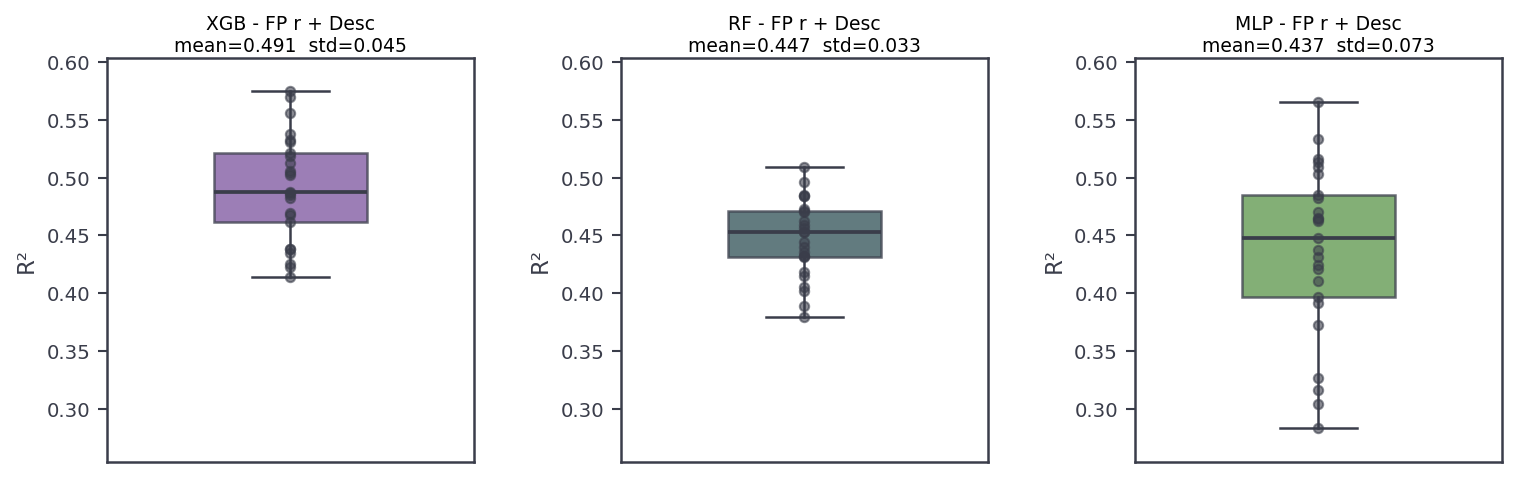

In [10]:
# ---------------------------------------------------------------------------
# Fig R-1: CV fold R² boxplots (one subplot per configuration)
# ---------------------------------------------------------------------------
def plot_cv_boxplots(fold_scores: dict, prefix: str = "") -> None:
    n     = len(fold_scores)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3.5 * nrows),
        gridspec_kw={"hspace": 0.5, "wspace": 0.4},
    )
    axes = axes.flatten()

    all_scores = [s for scores in fold_scores.values() for s in scores]
    padding    = (max(all_scores) - min(all_scores)) * 0.1
    ylim = (
        max(0.0, min(all_scores) - padding),
        min(1.0, max(all_scores) + padding),
    )

    # Assign one AIME colour per model family
    color_map = {"RF": DEEP_TEAL, "XGB": ROYAL_PURPLE, "MLP": FOREST_GREEN}

    for i, (label, scores) in enumerate(fold_scores.items()):
        ax    = axes[i]
        color = next((v for k, v in color_map.items() if k in label), DARK_SLATE)

        bp = ax.boxplot(
            [scores],
            positions    = [1],
            patch_artist = True,
            widths       = 0.5,
            medianprops  = dict(color=DARK_SLATE, linewidth=1.8),
            whiskerprops = dict(color=DARK_SLATE, linewidth=1.2),
            capprops     = dict(color=DARK_SLATE, linewidth=1.2),
            flierprops   = dict(
                marker="o", markersize=3,
                markerfacecolor=DARK_SLATE, alpha=0.4,
                markeredgecolor="none",
            ),
        )
        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.75)
        bp["boxes"][0].set_edgecolor(DARK_SLATE)
        bp["boxes"][0].set_linewidth(1.2)

        ax.scatter(
            np.ones(len(scores)), scores,
            color=DARK_SLATE, zorder=5, s=20, alpha=0.6,
        )

        ax.set_ylim(ylim)
        ax.set_xlim(0.4, 1.6)
        ax.set_xticks([])
        ax.set_ylabel("R²")
        ax.set_title(
            f"{label}\nmean={np.mean(scores):.3f}  std={np.std(scores):.3f}",
            fontsize=9, pad=3,
        )

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    save_fig(fig, f"{prefix}cv_boxplots")
    plt.show()


plot_cv_boxplots(fold_scores, prefix=EXPERIMENT)

Saved: figures/fullpredicted_vs_actual.png  +  figures/fullpredicted_vs_actual.pdf


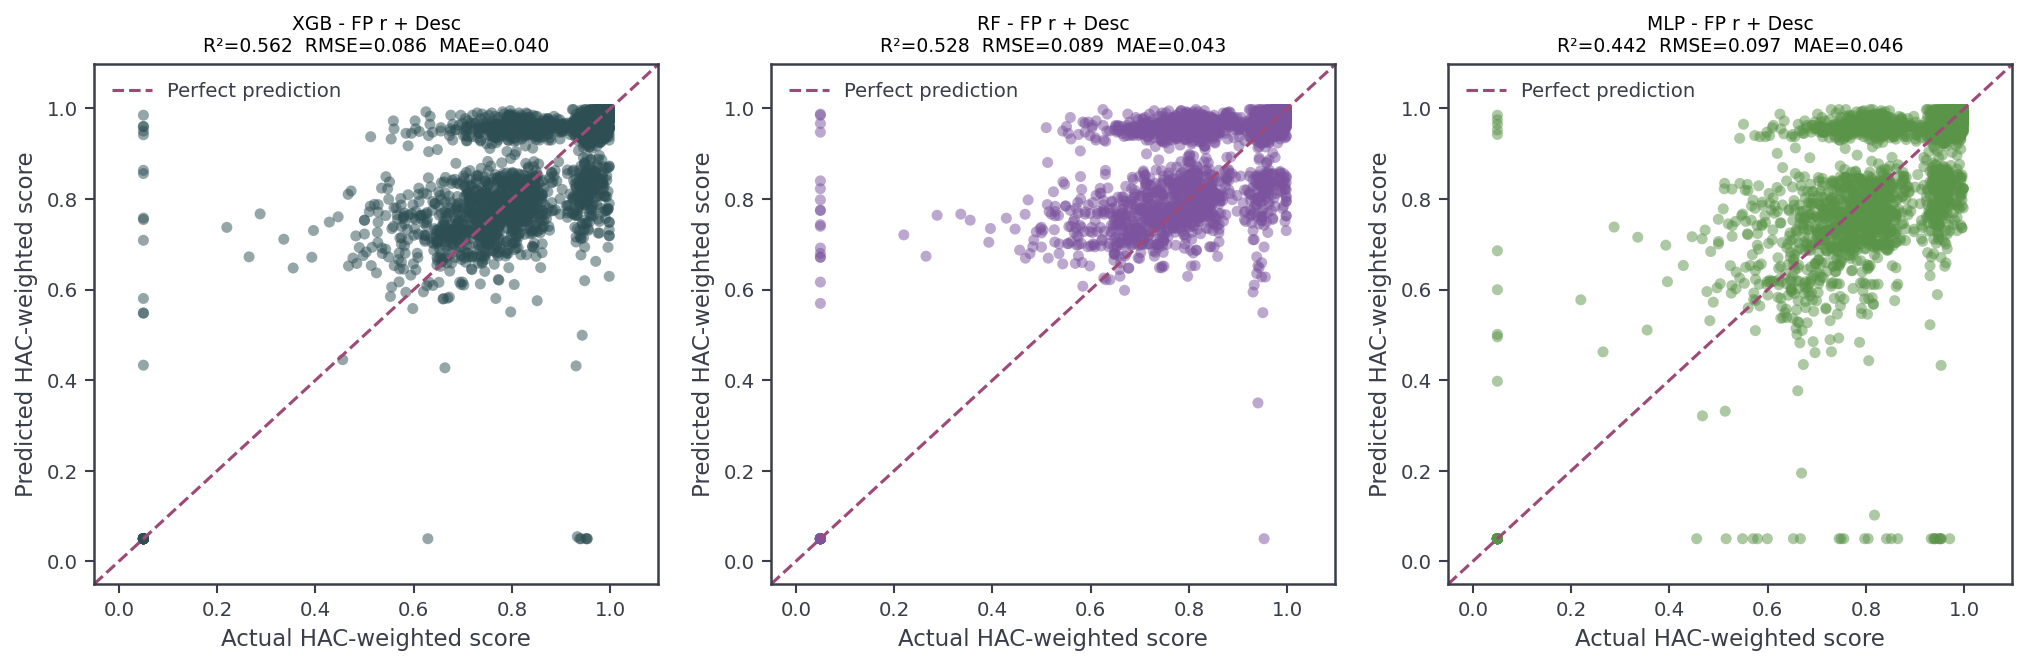

In [11]:
# ---------------------------------------------------------------------------
# Fig R-2: Predicted vs Actual — test set
# ---------------------------------------------------------------------------
def plot_predicted_vs_actual(pred_data: dict, metrics_df: pd.DataFrame, prefix: str = "") -> None:
    n   = len(pred_data)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.5))
    if n == 1:
        axes = [axes]

    colors = [DEEP_TEAL, ROYAL_PURPLE, FOREST_GREEN, MUTED_PLUM, SOFT_LAVENDER, DARK_SLATE]

    for ax, (name, data), color in zip(axes, pred_data.items(), colors):
        y_pred = np.array(data["y_pred"]).flatten()
        y_true = np.array(data["y_true"]).flatten()
        lim    = [
            min(y_true.min(), y_pred.min()) - 0.1,
            max(y_true.max(), y_pred.max()) + 0.1,
        ]

        ax.scatter(
            y_true, y_pred,
            alpha=0.5, edgecolors="none", s=28, color=color,
        )
        ax.plot(lim, lim, "--", color=MUTED_PLUM, linewidth=1.5, label="Perfect prediction")
        ax.set_xlabel("Actual HAC-weighted score")
        ax.set_ylabel("Predicted HAC-weighted score")
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.legend()

        r2   = metrics_df.loc[name, "R²"]
        rmse = metrics_df.loc[name, "RMSE"]
        mae  = metrics_df.loc[name, "MAE"]
        ax.set_title(f"{name}\nR²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}", fontsize=9)

    save_fig(fig, f"{prefix}predicted_vs_actual")
    plt.show()


plot_predicted_vs_actual(pred_data, metrics_df, prefix=EXPERIMENT)

Saved: figures/fullresiduals.png  +  figures/fullresiduals.pdf


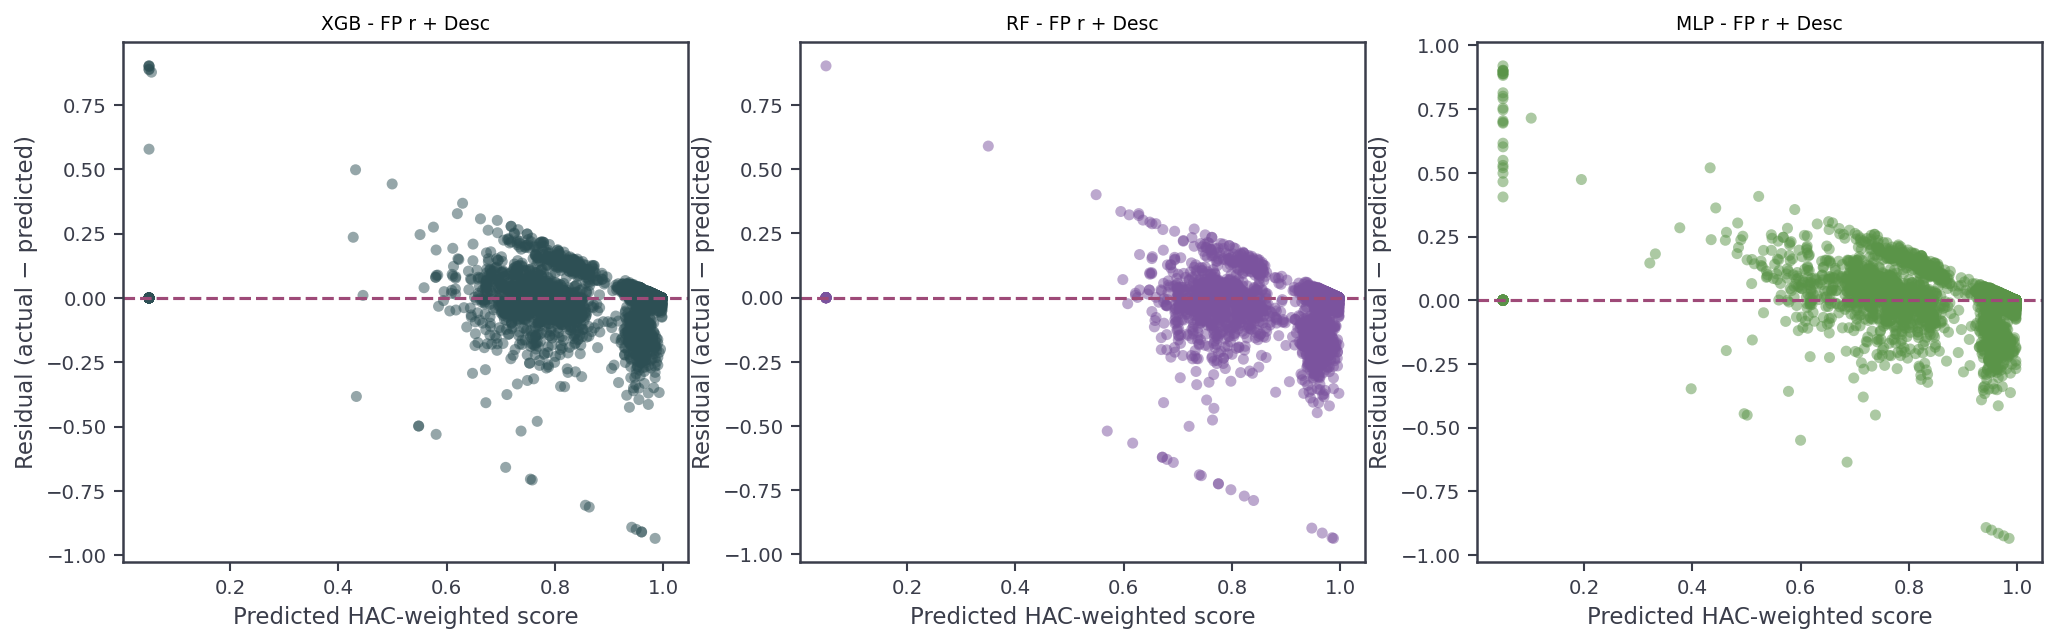

In [12]:
# ---------------------------------------------------------------------------
# Fig R-3: Residuals — test set
# ---------------------------------------------------------------------------
def plot_residuals(pred_data: dict, file_prefix: str = "") -> None:
    n   = len(pred_data)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.5))
    if n == 1:
        axes = [axes]

    colors = [DEEP_TEAL, ROYAL_PURPLE, FOREST_GREEN, MUTED_PLUM, SOFT_LAVENDER, DARK_SLATE]

    for ax, (name, data), color in zip(axes, pred_data.items(), colors):
        y_pred    = np.array(data["y_pred"]).flatten()
        y_true    = np.array(data["y_true"]).flatten()
        residuals = y_true - y_pred

        ax.scatter(y_pred, residuals, alpha=0.5, edgecolors="none", s=28, color=color)
        ax.axhline(0, color=MUTED_PLUM, linestyle="--", linewidth=1.5)
        ax.set_xlabel("Predicted HAC-weighted score")
        ax.set_ylabel("Residual (actual − predicted)")
        ax.set_title(name, fontsize=9)

    save_fig(fig, f"{file_prefix}residuals")
    plt.show()


plot_residuals(pred_data, file_prefix=EXPERIMENT)

In [13]:
# ---------------------------------------------------------------------------
# Metrics table — export to LaTeX
# ---------------------------------------------------------------------------
print(
    metrics_df[["R²", "RMSE", "MAE"]]
    .round(3)
    .to_latex(
        index=True,
        caption="Test set performance of all regression model configurations.",
        label="tab:reg_metrics",
        column_format="lrrr",
        bold_rows=False,
    )
)

\begin{table}
\caption{Test set performance of all regression model configurations.}
\label{tab:reg_metrics}
\begin{tabular}{lrrr}
\toprule
 & R² & RMSE & MAE \\
Model &  &  &  \\
\midrule
XGB - FP r + Desc & 0.562000 & 0.086000 & 0.040000 \\
RF - FP r + Desc & 0.528000 & 0.089000 & 0.043000 \\
MLP - FP r + Desc & 0.442000 & 0.097000 & 0.046000 \\
\bottomrule
\end{tabular}
\end{table}



Saved: figures/fullreg_multiple_comparisons.png  +  figures/fullreg_multiple_comparisons.pdf


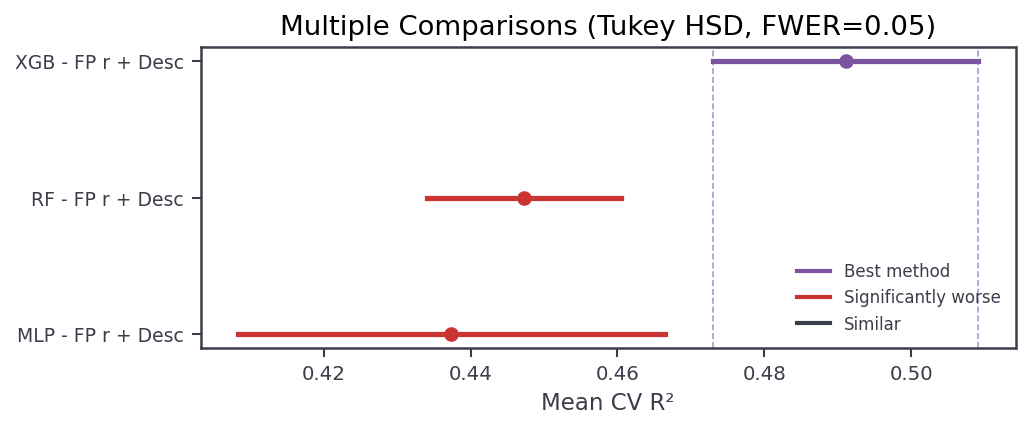

In [26]:
# ---------------------------------------------------------------------------
# Fig R-4: Multiple comparisons — repeated measures Tukey HSD
#          Horizontal mean ± CI plot following Ash et al. (2024) protocol
# ---------------------------------------------------------------------------
import warnings
import pingouin as pg
from statsmodels.stats.libqsturng import psturng, qsturng
from matplotlib.lines import Line2D


def rm_tukey_hsd(df, metric, group_col, alpha=0.05):
    """Repeated measures Tukey HSD test following Ash et al. (2024)."""
    df_means = df.groupby(group_col).mean(numeric_only=True)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        aov = pg.rm_anova(
            dv=metric, within=group_col, subject="cv_cycle",
            data=df, detailed=True,
        )

    mse        = aov.loc[1, "MS"]
    df_resid   = aov.loc[1, "DF"]
    methods    = df_means.index
    n_per_group = df[group_col].value_counts().mean()
    tukey_se   = np.sqrt(2 * mse / n_per_group)
    q          = qsturng(1 - alpha, len(methods), df_resid)

    pc = pd.DataFrame(index=methods, columns=methods, data=1.0)
    df_means_diff = pd.DataFrame(index=methods, columns=methods, data=0.0)

    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            if i < j:
                g1        = df[df[group_col] == m1][metric]
                g2        = df[df[group_col] == m2][metric]
                mean_diff = g1.mean() - g2.mean()
                sr        = np.abs(mean_diff) / tukey_se
                adj_p     = psturng(sr * np.sqrt(2), len(methods), df_resid)
                if isinstance(adj_p, np.ndarray):
                    adj_p = adj_p[0]
                pc.loc[m1, m2] = adj_p
                pc.loc[m2, m1] = adj_p
                df_means_diff.loc[m1, m2] =  mean_diff
                df_means_diff.loc[m2, m1] = -mean_diff

    return df_means, df_means_diff, pc.astype(float)


def plot_multiple_comparisons(df_cv, metric="r2", prefix="", alpha=0.05):
    """Horizontal mean ± CI plot following Ash et al. (2024) Fig. 1."""

    df_means, _, pc = rm_tukey_hsd(df_cv, metric, group_col="method", alpha=alpha)

    # Sort by mean (descending = best on top)
    df_means = df_means.sort_values(metric, ascending=True)
    labels   = df_means.index.tolist()
    means    = df_means[metric].values
    best     = labels[-1]   # highest mean = best model

    # Compute 95% CI from df_cv directly
    ci_low, ci_high = [], []
    for label in labels:
        scores = df_cv[df_cv["method"] == label][metric].values
        n      = len(scores)
        se     = scores.std(ddof=1) / np.sqrt(n)
        t_crit = 1.96
        ci_low.append(scores.mean()  - t_crit * se)
        ci_high.append(scores.mean() + t_crit * se)

    # Significantly worse than best = p < alpha vs best model
    sig_worse = [
        l for l in labels
        if l != best and pc.loc[best, l] < alpha
    ]

    color_map = {"RF": DEEP_TEAL, "XGB": ROYAL_PURPLE, "MLP": FOREST_GREEN}
    colors = []
    for l in labels:
        if l == best:
            colors.append(ROYAL_PURPLE)
        elif l in sig_worse:
            colors.append("#CC3333")
        else:
            colors.append(DARK_SLATE)

    fig, ax = plt.subplots(figsize=(7, max(3, len(labels) * 0.8)))
    y = np.arange(len(labels))

    for i, (label, m, lo, hi, c) in enumerate(
        zip(labels, means, ci_low, ci_high, colors)
    ):
        ax.plot([lo, hi], [i, i], color=c, linewidth=2.5)
        ax.plot(m, i, "o", color=c, markersize=6)

    # Dashed vertical lines at best model CI bounds
    best_idx = labels.index(best)
    ax.axvline(
        ci_low[best_idx],  color=ROYAL_PURPLE,
        linestyle="--", linewidth=0.8, alpha=0.6,
    )
    ax.axvline(
        ci_high[best_idx], color=ROYAL_PURPLE,
        linestyle="--", linewidth=0.8, alpha=0.6,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Mean CV R²")
    ax.set_title("Multiple Comparisons (Tukey HSD, FWER=0.05)")

    legend_elements = [
        Line2D([0], [0], color=ROYAL_PURPLE, linewidth=2,
               label="Best method"),
        Line2D([0], [0], color="#CC3333",     linewidth=2,
               label="Significantly worse"),
        Line2D([0], [0], color=DARK_SLATE,    linewidth=2,
               label="Similar"),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

    plt.tight_layout()
    save_fig(fig, f"{prefix}reg_multiple_comparisons")
    plt.show()


plot_multiple_comparisons(df_cv, metric="r2", prefix=EXPERIMENT)

Note: using rankdf for annotations (no pairwise p-values available).
Saved: figures/full_reg_r2_ci.png  +  figures/full_reg_r2_ci.pdf


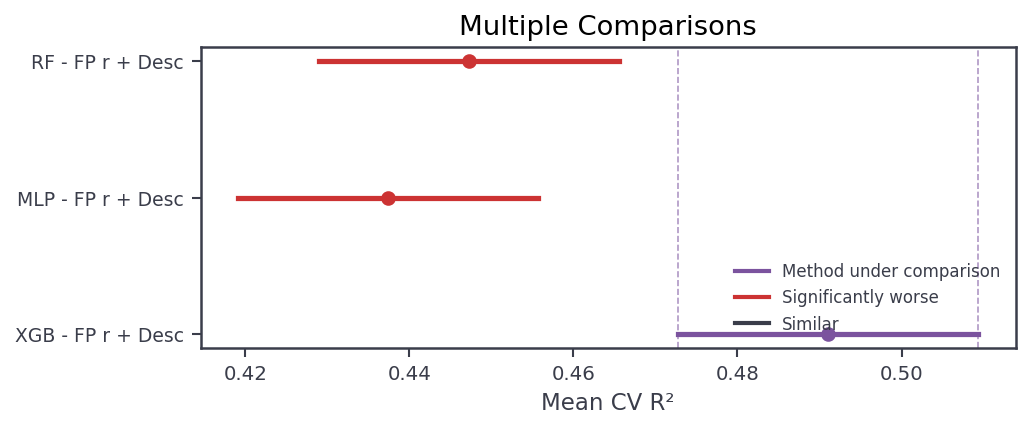

In [27]:
# ---------------------------------------------------------------------------
# Fig R-5: Model performance — mean CV R² with std error bars
#          and pairwise significance brackets from AutoRank
# ---------------------------------------------------------------------------
from itertools import combinations

# Load pairwise p-values saved by evaluation.py
pvalue_path  = REG_RESULTS / "pairwise_pvalues.csv"
rankdf_path  = REG_RESULTS / "autorank_rankdf.csv"

pvalue_df = None
rankdf    = None

if pvalue_path.exists():
    pvalue_df = pd.read_csv(pvalue_path, index_col=0)
elif rankdf_path.exists():
    rankdf = pd.read_csv(rankdf_path, index_col=0)
    print("Note: using rankdf for annotations (no pairwise p-values available).")


def plot_r2_with_ci(rankdf, name, best_model="XGB - FP r + Desc", alpha=0.05):
    """Horizontal mean ± CI plot matching the Ash et al. protocol figure."""
    
    # Sort by mean rank (ascending = best first on y-axis)
    rankdf = rankdf.sort_values("meanrank")
    labels = rankdf.index.tolist()
    means  = rankdf["mean"].values
    ci_low = rankdf["ci_lower"].values
    ci_high = rankdf["ci_upper"].values

    # Color coding: blue = best, red = significantly worse, grey = similar
    sig_worse = ["RF - FP r + Desc", "MLP - FP r + Desc"]  # from Tukey HSD output
    colors = []
    for l in labels:
        if l == best_model:
            colors.append(ROYAL_PURPLE)
        elif l in sig_worse:
            colors.append("#CC3333")
        else:
            colors.append(DARK_SLATE)

    fig, ax = plt.subplots(figsize=(7, 3))
    y = np.arange(len(labels))

    for i, (label, m, lo, hi, c) in enumerate(zip(labels, means, ci_low, ci_high, colors)):
        ax.plot([lo, hi], [i, i], color=c, linewidth=2.5)
        ax.plot(m, i, "o", color=c, markersize=6)

    # Dashed vertical lines at best model CI bounds
    best_idx = labels.index(best_model)
    ax.axvline(ci_low[best_idx],  color=ROYAL_PURPLE, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axvline(ci_high[best_idx], color=ROYAL_PURPLE, linestyle="--", linewidth=0.8, alpha=0.6)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Mean CV R²")
    ax.set_title("Multiple Comparisons")

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=ROYAL_PURPLE, linewidth=2, label="Method under comparison"),
        Line2D([0], [0], color="#CC3333",     linewidth=2, label="Significantly worse"),
        Line2D([0], [0], color=DARK_SLATE,    linewidth=2, label="Similar"),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

    plt.tight_layout()
    save_fig(fig, name)
    plt.show()


plot_r2_with_ci(rankdf, name=f"{EXPERIMENT}_reg_r2_ci")

---
## 4. Tanimoto filtering figures

**Prerequisites:** run on Alvis:
```bash
python src/regression_model/filter_training_set.py
```
Then download `data/processed/surrogate_model/tanimoto_similarities.csv` and `fragment_analysis.csv` locally.

In [17]:
# ---------------------------------------------------------------------------
# Load filtering results
# ---------------------------------------------------------------------------
tanimoto_df = pd.read_csv(SURROGATE / "tanimoto_similarities.csv")
fragment_df = pd.read_csv(SURROGATE / "fragment_analysis.csv")

n_removed = int(fragment_df["n_removed"].iloc[0])
n_kept    = int(fragment_df["n_kept"].iloc[0])

print(f"Unsolved molecules — removed: {n_removed}  kept: {n_kept}")
print(f"Similarity scores loaded: {len(tanimoto_df)} molecules")
print(f"Fragment tests loaded: {len(fragment_df)} fragments")

Unsolved molecules — removed: 4237  kept: 2851
Similarity scores loaded: 7088 molecules
Fragment tests loaded: 62 fragments


Saved: figures/tanimoto_similarity_distribution.png  +  figures/tanimoto_similarity_distribution.pdf


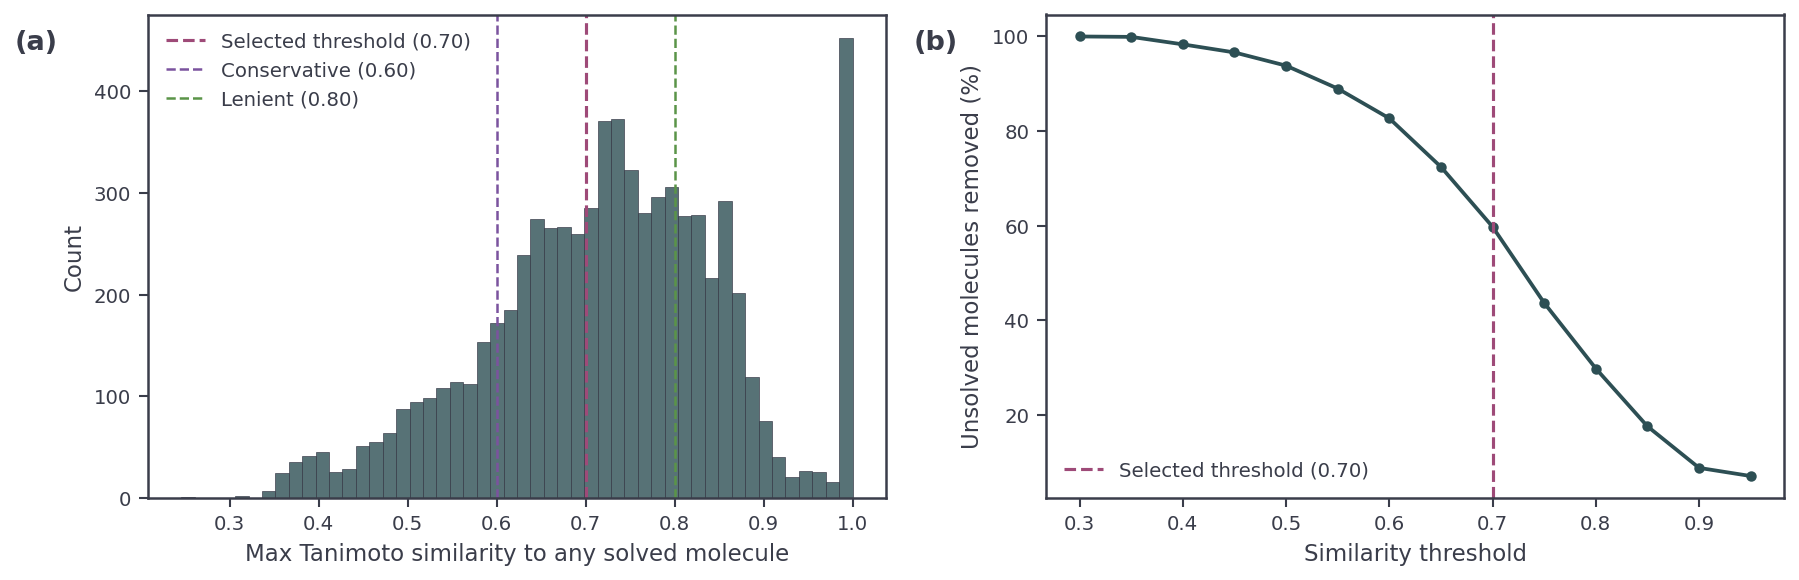

In [18]:
# ---------------------------------------------------------------------------
# Fig F-1: Tanimoto similarity distribution + threshold impact
# ---------------------------------------------------------------------------
def plot_tanimoto_distribution(tanimoto_df, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (a) Distribution of max similarities
    ax = axes[0]
    ax.hist(
        tanimoto_df["max_sim_to_solved"], bins=50,
        color=DEEP_TEAL, alpha=0.8, edgecolor=DARK_SLATE, linewidth=0.4,
    )
    ax.axvline(x=0.7, color=MUTED_PLUM,   linestyle="--", linewidth=1.5, label="Selected threshold (0.70)")
    ax.axvline(x=0.6, color=ROYAL_PURPLE, linestyle="--", linewidth=1.2, label="Conservative (0.60)")
    ax.axvline(x=0.8, color=FOREST_GREEN, linestyle="--", linewidth=1.2, label="Lenient (0.80)")
    ax.set_xlabel("Max Tanimoto similarity to any solved molecule")
    ax.set_ylabel("Count")
    ax.legend()
    add_panel_label(ax, "(a)")

    # (b) % removed at each threshold
    ax = axes[1]
    thresholds  = np.arange(0.3, 1.0, 0.05)
    pct_removed = [
        (tanimoto_df["max_sim_to_solved"] > t).mean() * 100
        for t in thresholds
    ]
    ax.plot(thresholds, pct_removed, color=DEEP_TEAL, marker="o", markersize=4)
    ax.axvline(x=0.7, color=MUTED_PLUM, linestyle="--", linewidth=1.5, label="Selected threshold (0.70)")
    ax.set_xlabel("Similarity threshold")
    ax.set_ylabel("Unsolved molecules removed (%)")
    ax.legend()
    add_panel_label(ax, "(b)")

    plt.tight_layout(w_pad=2.0)
    save_fig(fig, name)
    plt.show()


plot_tanimoto_distribution(tanimoto_df, name="tanimoto_similarity_distribution")

Fragments shown: 23 of 37 significant
Saved: figures/fragment_enrichment.png  +  figures/fragment_enrichment.pdf


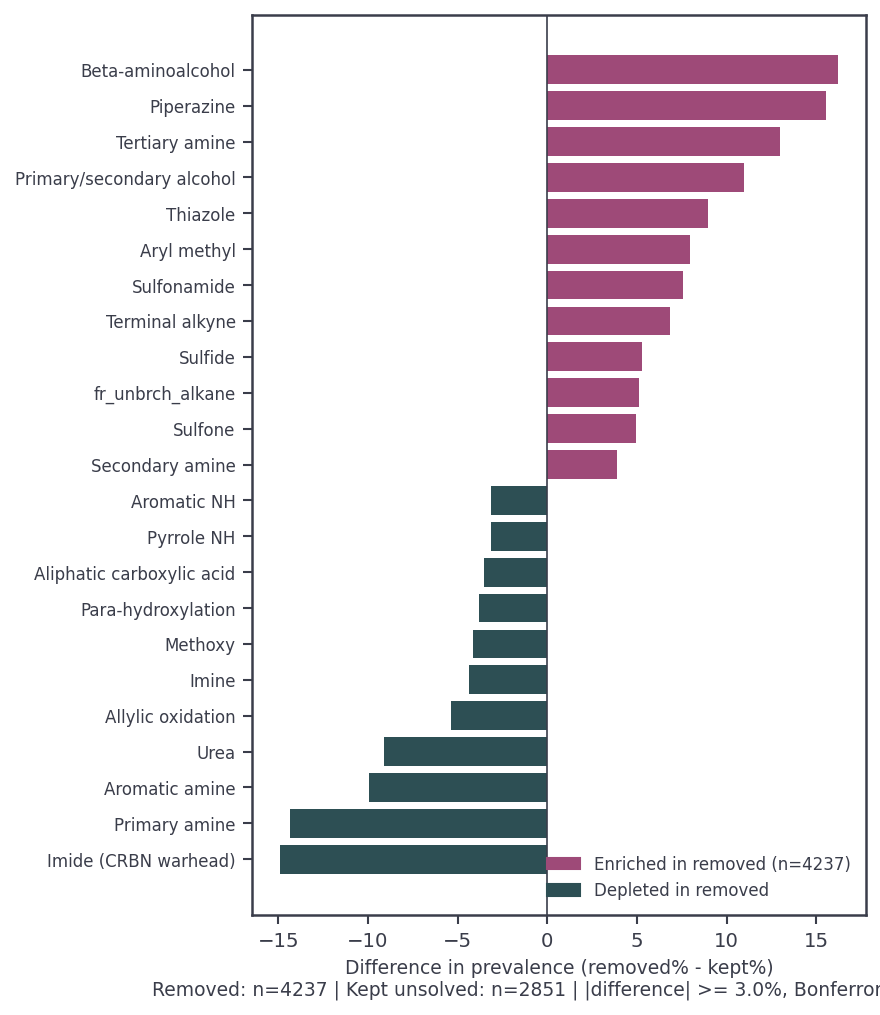

In [19]:
# ---------------------------------------------------------------------------
# Fig F-2: Functional group enrichment in removed vs kept molecules
# ---------------------------------------------------------------------------
from matplotlib.patches import Patch

RENAME_MAP = {
    "fr_nitro_arom":         "Nitroaromatic",
    "fr_nitro":              "Nitro group",
    "fr_sulfone":            "Sulfone",
    "fr_sulfide":            "Sulfide",
    "fr_sulfonamd":          "Sulfonamide",
    "fr_term_acetylene":     "Terminal alkyne",
    "fr_thiazole":           "Thiazole",
    "fr_HOCCN":              "Beta-aminoalcohol",
    "fr_imide":              "Imide (CRBN warhead)",
    "fr_urea":               "Urea",
    "fr_NH2":                "Primary amine",
    "fr_ArN":                "Aromatic amine",
    "fr_priamide":           "Primary amide",
    "fr_guanido":            "Guanidine",
    "fr_Ndealkylation2":     "Tertiary amine",
    "fr_piperzine":          "Piperazine",
    "fr_Al_OH_noTert":       "Primary/secondary alcohol",
    "fr_aryl_methyl":        "Aryl methyl",
    "fr_Ar_COO":             "Aromatic carboxylic acid",
    "fr_Ndealkylation1":     "Secondary amine",
    "fr_dihydropyridine":    "Dihydropyridine",
    "fr_amidine":            "Amidine",
    "fr_phos_acid":          "Phosphoric acid",
    "fr_phos_ester":         "Phosphoric ester",
    "fr_imidazole":          "Imidazole",
    "fr_COO":                "Carboxylic acid",
    "fr_Al_COO":             "Aliphatic carboxylic acid",
    "fr_Nhpyrrole":          "Pyrrole NH",
    "fr_Ar_NH":              "Aromatic NH",
    "fr_phenol":             "Phenol",
    "fr_Imine":              "Imine",
    "fr_allylic_oxid":       "Allylic oxidation",
    "fr_methoxy":            "Methoxy",
    "fr_para_hydroxylation": "Para-hydroxylation",
}

IGNORE = [
    "fr_benzene", "fr_bicyclic", "fr_piperdine",
    "fr_ether", "fr_halogen", "fr_Al_OH",
    "fr_phenol_noOrthoHbond", "fr_COO2",
    "fr_Ar_OH", "fr_alkyl_halide",
]

MIN_DIFFERENCE = 3.0


def plot_fragment_enrichment(fragment_df, n_removed, n_kept, name):
    plot_df = fragment_df[
        fragment_df["significant"] &
        ~fragment_df["fragment"].isin(IGNORE)
    ].copy()

    plot_df["fragment"] = plot_df["fragment"].map(RENAME_MAP).fillna(plot_df["fragment"])
    plot_df = plot_df[plot_df["difference_%"].abs() >= MIN_DIFFERENCE]
    plot_df = plot_df.sort_values("difference_%")

    print(f"Fragments shown: {len(plot_df)} of {fragment_df['significant'].sum()} significant")

    colors = [MUTED_PLUM if x > 0 else DEEP_TEAL for x in plot_df["difference_%"]]

    fig, ax = plt.subplots(figsize=(6, max(4, len(plot_df) * 0.3)))
    ax.barh(plot_df["fragment"], plot_df["difference_%"], color=colors)
    ax.axvline(x=0, color=DARK_SLATE, linewidth=0.8)
    ax.set_xlabel(
        f"Difference in prevalence (removed% - kept%)\n"
        f"Removed: n={n_removed} | Kept unsolved: n={n_kept} | "
        f"|difference| >= {MIN_DIFFERENCE}%, Bonferroni p<0.05",
        fontsize=9,
    )
    ax.tick_params(axis="y", labelsize=8)

    legend = [
        Patch(color=MUTED_PLUM, label=f"Enriched in removed (n={n_removed})"),
        Patch(color=DEEP_TEAL,  label="Depleted in removed"),
    ]
    ax.legend(handles=legend, loc="lower right", fontsize=8)
    plt.tight_layout()
    save_fig(fig, name)
    plt.show()


plot_fragment_enrichment(fragment_df, n_removed, n_kept, name="fragment_enrichment")